In [1]:
import scanpy as sc
import numpy as np
import flowkit as fk
from matplotlib import pyplot as plt
import pandas as pd
from scipy.stats import gaussian_kde
from scipy.signal import find_peaks

In [44]:
sample1 = fk.Sample('BLD_CD45AF_CD3/d261_bld_17_m_ctr_wht_nrm_nsm_cmvn_ebvp_toxd_yng_ncopd_anx_230525_CD45AF_CD3.fcs')
df1 = sample1.as_dataframe(source = 'raw')
df1.columns = [pns if pns != '' else pnn for pnn, pns in df1.columns]

In [43]:
sample2 = fk.Sample('BLD_CD45AF_CD3/d274_bld_14_f_ctr_wht_nrm_nsm_cmvn_ebvp_toxd_yng_ncopd_str_230525_CD45AF_CD3.fcs')
df2 = sample2.as_dataframe(source = 'raw')
df2.columns = [pns if pns != '' else pnn for pnn, pns in df2.columns]

In [ ]:
# exclude = ['FSC-A', 'FSC-H', 'SSC-A', 'SSC-H', 'Time', 'SSC-B-A', "SSC-B-H", "AF-A", 'CD66bCD19CD326LD', 'CD45']
# df1 = df1.drop(columns=exclude)
# df2 = df2.drop(columns=exclude)

In [45]:
#remove outliers from df1['CD4'] and df2['CD4']
df1 = df1[df1['CD4'] < np.percentile(df1['CD4'], 99)]
df2 = df2[df2['CD4'] < np.percentile(df2['CD4'], 99)]

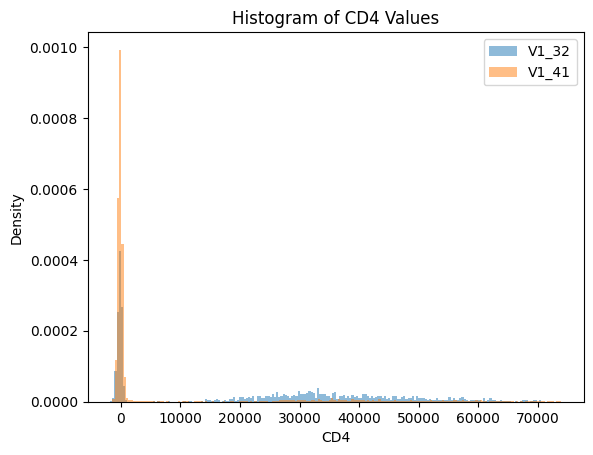

In [46]:
hist1, bins1 = np.histogram(df1['CD4'], bins=200)
hist2, bins2 = np.histogram(df2['CD4'], bins=200)

plt.hist(df1['CD4'], bins=bins1, density=True, alpha=0.5, label='V1_32')
plt.hist(df2['CD4'], bins=bins2, density=True, alpha=0.5, label='V1_41')
plt.legend()
plt.title('Histogram of CD4 Values')
plt.xlabel('CD4')
plt.ylabel('Density')
plt.show()

In [47]:
median_CD4_df1 = np.mean(df1['CD4'])
median_CD4_df2 = np.mean(df2['CD4'])
print('Median CD4 in df1:', median_CD4_df1)
print('Median CD4 in df2:', median_CD4_df2)

Median CD4 in df1: 22379.16888456161
Median CD4 in df2: 6352.345579088554


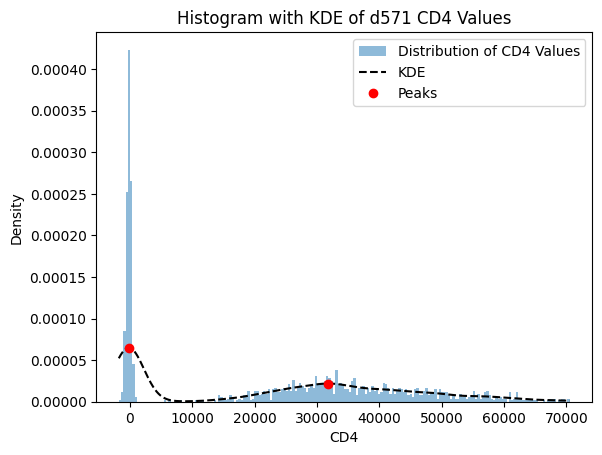

In [48]:
hist, bins = np.histogram(df1['CD4'], bins=200)
x = np.linspace(min(df1['CD4']), max(df1['CD4']), 1000)

kde = gaussian_kde(df1['CD4'])
kde.set_bandwidth(bw_method=kde.factor * 0.5)  
peaks, _ = find_peaks(kde(x))

plt.hist(df1['CD4'], bins=bins, density=True, alpha=0.5, label='Distribution of CD4 Values')
plt.plot(x, kde(x), 'k--', label='KDE')
plt.plot(x[peaks], kde(x[peaks]), 'ro', label='Peaks')
plt.legend()
plt.title('Histogram with KDE of d571 CD4 Values')
plt.xlabel('CD4')
plt.ylabel('Density')
plt.show()

In [49]:
confidence_scores = {}
bw = kde.factor * (max(x) - min(x))

for p in peaks:
    x_p = x[p]
    k_p = kde(x_p)
    window_mask = (x >= (x_p - bw/2)) & (x <= (x_p + bw/2))
    i = x[window_mask]
    k_i = kde(i)
    s_p = ((np.sum(k_p - k_i))* k_p)[0]
    confidence_scores[p] = [x_p, s_p]

df_confidence = pd.DataFrame(confidence_scores).T
df_confidence.columns = ['x_p', 's_p']

In [50]:
threshold = (max(df1['CD4']) - min(df1['CD4'])) * 0.1
x_p = df_confidence['x_p']
x_p = np.array([x_p])[0]

groups = {}
k = 0
while k < len(x_p):
    if k == len(x_p) - 1:
        if x_p[k] in groups:
            k += 1
            break
        else:
            groups[x_p[k]] = k
            k += 1
            break   
    
    if x_p[k+1] - x_p[k] < threshold:
        if x_p[k] in groups:
            groups[x_p[k+1]] = groups[x_p[k]]
        else:
            groups[x_p[k]] = k
            groups[x_p[k+1]] = k
    else:
        if x_p[k] in groups:
            pass
        else:
            groups[x_p[k]] = k
    k += 1

groups = pd.DataFrame(groups.items(), columns=['x_p', 'group'])
df_merged = df_confidence.merge(groups, on='x_p')
df_merged

,x_p,s_p,group
0,-197.353486,8.982936e-08,0
1,31809.189397,3.712518e-09,1


In [51]:
df1 = df_merged.loc[df_merged.groupby("group")["s_p"].idxmax()]
df1 = df1.sort_values(by='s_p', ascending=False)
df1 = df1.head(2)
df1

,x_p,s_p,group
0,-197.353486,8.982936e-08,0
1,31809.189397,3.712518e-09,1


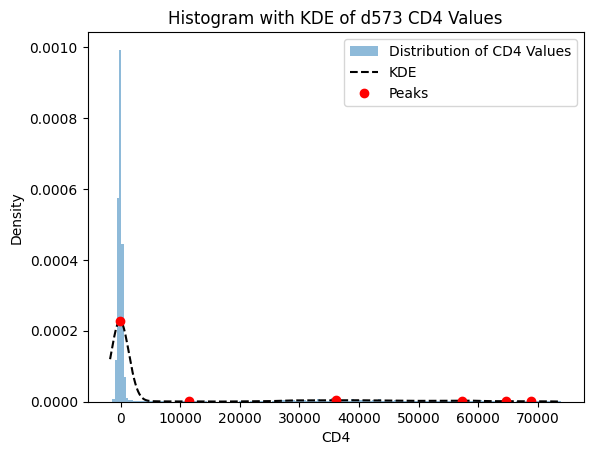

In [52]:
hist, bins = np.histogram(df2['CD4'], bins=200)
x = np.linspace(min(df2['CD4']), max(df2['CD4']), 1000)

kde = gaussian_kde(df2['CD4'])
kde.set_bandwidth(bw_method=kde.factor * 0.5)  
peaks, _ = find_peaks(kde(x))

plt.hist(df2['CD4'], bins=bins, density=True, alpha=0.5, label='Distribution of CD4 Values')
plt.plot(x, kde(x), 'k--', label='KDE')
plt.plot(x[peaks], kde(x[peaks]), 'ro', label='Peaks')
plt.legend()
plt.title('Histogram with KDE of d573 CD4 Values')
plt.xlabel('CD4')
plt.ylabel('Density')
plt.show()

In [53]:
confidence_scores = {}
bw = kde.factor * (max(x) - min(x))

for p in peaks:
    x_p = x[p]
    k_p = kde(x_p)
    window_mask = (x >= (x_p - bw/2)) & (x <= (x_p + bw/2))
    i = x[window_mask]
    k_i = kde(i)
    s_p = ((np.sum(k_p - k_i))* k_p)[0]
    confidence_scores[p] = [x_p, s_p]

df_confidence = pd.DataFrame(confidence_scores).T
df_confidence.columns = ['x_p', 's_p']

In [54]:
threshold = (max(df2['CD4']) - min(df2['CD4'])) * 0.05
x_p = df_confidence['x_p']
x_p = np.array([x_p])[0]
print(threshold)

groups = {}
k = 0
while k < len(x_p):
    if k == len(x_p) - 1:
        if x_p[k] in groups:
            k += 1
            break
        else:
            groups[x_p[k]] = k
            k += 1
            break   
    
    if x_p[k+1] - x_p[k] < threshold:
        if x_p[k] in groups:
            groups[x_p[k+1]] = groups[x_p[k]]
        else:
            groups[x_p[k]] = k
            groups[x_p[k+1]] = k
    else:
        if x_p[k] in groups:
            pass
        else:
            groups[x_p[k]] = k
    k += 1

groups = pd.DataFrame(groups.items(), columns=['x_p', 'group'])
df_merged = df_confidence.merge(groups, on='x_p')
df_merged

3782.9491333007813


,x_p,s_p,group
0,-114.686071,1.276936e-06,0
1,11472.725689,1.240372e-11,1
2,36086.508838,5.414762e-11,2
3,57216.494988,5.936047e-11,3
4,64638.497292,2.703069e-11,4
5,68803.906748,2.698991e-12,5


In [55]:
df2 = df_merged.loc[df_merged.groupby("group")["s_p"].idxmax()]
df2 = df2.sort_values(by='s_p', ascending=False)
df2 = df2.head(2)
df2

,x_p,s_p,group
0,-114.686071,1.276936e-06,0
3,57216.494988,5.936047e-11,3


In [56]:
p1 = df1.reset_index(drop=True)
p2 = df2.reset_index(drop=True)

In [57]:
landmarks = np.arange(1, 3)
p1['landmark'] = landmarks
p2['landmark'] = landmarks 

In [58]:
p1

,x_p,s_p,group,landmark
0,-197.353486,8.982936e-08,0,1
1,31809.189397,3.712518e-09,1,2


In [21]:
merged_df = pd.concat([p1, p2])
B = merged_df.groupby('landmark', as_index=False)['x_p'].median()['x_p']
B = np.array([B])[0]
B

array([ -135.92144665, 33970.91054977])

In [22]:
sample1 = fk.Sample('BLD_CD45AF_CD3/d575_bld_45_f_ctr_blk_ovr_nsm_cmvp_ebvp_toxn_mid_ncopd_str_221117_CD45AF_CD3.fcs')
df1 = sample1.as_dataframe(source = 'raw')
df1.columns = [pns if pns != '' else pnn for pnn, pns in df1.columns]

sample2 = fk.Sample('BLD_CD45AF_CD3/d573_bld_52_m_ftl_hsp_obs_nsm_cmvp_ebvn_toxn_mid_ncopd_anx_221117_CD45AF_CD3.fcs')
df2 = sample2.as_dataframe(source = 'raw')
df2.columns = [pns if pns != '' else pnn for pnn, pns in df2.columns]

In [23]:
df1 = df1[df1['CD4'] < np.percentile(df1['CD4'], 99)]
df2 = df2[df2['CD4'] < np.percentile(df2['CD4'], 99)]

In [24]:
D1 = df1['CD4']
D2 = df2['CD4']
D1 = np.array(D1)
D2 = np.array(D2)

In [25]:
before = D2.copy()

In [26]:
p_len= len(p1['x_p'])
p = p1['landmark']
p = np.array(landmarks)

p1 = p1['x_p']
p1 = np.array([p1])[0]

i = 0
phi = lambda x, s: np.exp(-(x**2) / (2*s))
sigma = np.std(D1)


while i < p_len:
    k = 0
    while k < len(D1):
        D1[k] += phi(abs(D1[k] - p1[i]), sigma**2) * (p1[i] - B[i])
        k += 1
    i += 1

In [27]:
p_len= len(p2['x_p'])
p = p2['landmark']
p = np.array(landmarks)

p2 = p2['x_p']
p2 = np.array([p2])[0]

i = 0
phi = lambda x, s: np.exp(-(x**2) / (2*s))
sigma = np.std(D2)

while i < p_len:
    k = 0
    while k < len(D2):
        D2[k] += phi(abs(D2[k] - p1[i]), sigma**2) * (p2[i] - B[i])
        k += 1
    i += 1

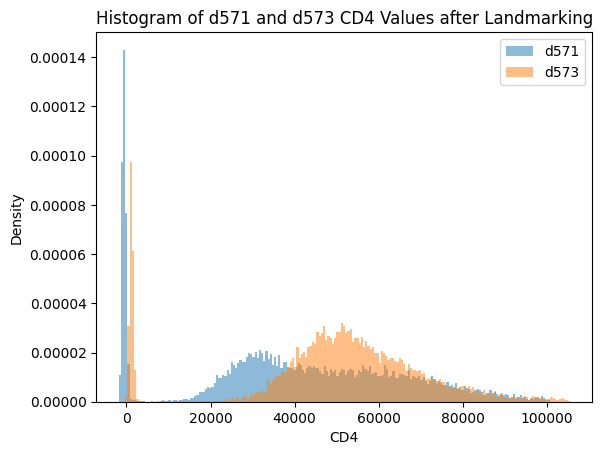

In [28]:
#plot histogram of D1 and D2 together
hist1, bins1 = np.histogram(D1, bins=200)
hist2, bins2 = np.histogram(D2, bins=200)

plt.hist(D1, bins=bins1, density=True, alpha=0.5, label='d571')
plt.hist(D2, bins=bins2, density=True, alpha=0.5, label='d573')
plt.legend()
plt.title('Histogram of d571 and d573 CD4 Values after Landmarking')
plt.xlabel('CD4')
plt.ylabel('Density')
plt.show()

In [29]:
sample1 = fk.Sample('BLD_CD45AF_CD3/d575_bld_45_f_ctr_blk_ovr_nsm_cmvp_ebvp_toxn_mid_ncopd_str_221117_CD45AF_CD3.fcs')
df1 = sample1.as_dataframe(source = 'raw')
df1.columns = [pns if pns != '' else pnn for pnn, pns in df1.columns]

sample2 = fk.Sample('BLD_CD45AF_CD3/d573_bld_52_m_ftl_hsp_obs_nsm_cmvp_ebvn_toxn_mid_ncopd_anx_221117_CD45AF_CD3.fcs')
df2 = sample2.as_dataframe(source = 'raw')
df2.columns = [pns if pns != '' else pnn for pnn, pns in df2.columns]

In [30]:
#remove outliers from df1['CD4'] and df2['CD4']
df1 = df1[df1['CD4'] < np.percentile(df1['CD4'], 99)]
df2 = df2[df2['CD4'] < np.percentile(df2['CD4'], 99)]

In [31]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
df1['CD4'] = scaler.fit_transform(df1[['CD4']])
df2['CD4'] = scaler.transform(df2[['CD4']])

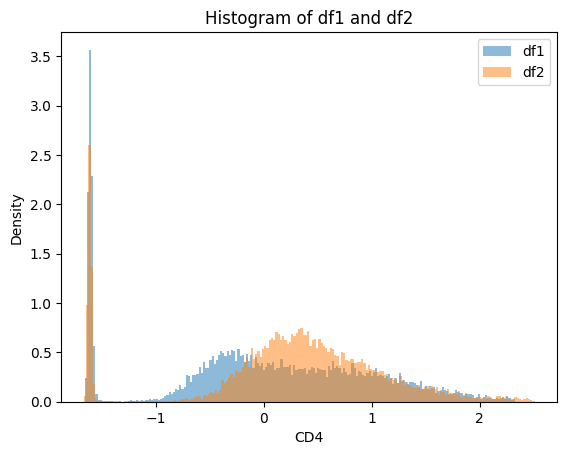

In [32]:
hist1, bins1 = np.histogram(df1['CD4'], bins=200)
hist2, bins2 = np.histogram(df2['CD4'], bins=200)

plt.hist(df1['CD4'], bins=bins1, density=True, alpha=0.5, label='df1')
plt.hist(df2['CD4'], bins=bins2, density=True, alpha=0.5, label='df2')
plt.legend()
plt.title('Histogram of df1 and df2')
plt.xlabel('CD4')
plt.ylabel('Density')
plt.show()